
### EDA 101


#### Introduction

Exploratory Data Analysis (EDA) is the initial and an essential step in your data analysis process. Here, we will explore a sales dataset that tracks the sales of two products over time. Our goal is to understand the underlying patterns, relationships, and outliers in the data.




### 1. Setting Up the Environment

#### 1.1. Importing Necessary Libraries




To start our EDA, we first need to load the dataset. We'll use the `pandas` library, a powerful tool for data manipulation and analysis in Python. We will also use `plotly` to generate beautiful plots.


In [51]:
%pip install pandas 
%pip install plotly

import pandas as pd
import plotly.express as px


[notice] A new release of pip is available: 24.0 -> 24.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 24.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



### Loading the Data (from CSV)

#### 2.1. Loading the Data



In [91]:
df_tourists = pd.read_csv('tourist_data_weekly.csv')

#### 2.2 Initial Data Peek

In [92]:
df_tourists.head()

,date,Tourists Total,United States,China,Australia,France,Germany,United Kingdom,Russia,India
0,01/01/2024,52084,1429,2879,1662,2481,3400,4168,7793,8603
1,01/02/2021,674,15,23,0,0,49,16,24,16
2,01/03/2021,1146,67,92,0,0,192,100,84,70
3,01/04/2024,37232,1394,2130,1801,2199,2462,3295,3777,6829
4,01/05/2023,20836,810,1044,1051,604,1714,1497,1941,5756


In [97]:
# Normalize the date column to ensure consistent formatting
df_tourists['date'] = pd.to_datetime(df_tourists['date'], format='%d/%m/%Y')

# Sort the DataFrame by the date column
df_sorted = df_tourists.sort_values(by='date')

# Display the sorted DataFrame
print(df_sorted)

          date  Tourists Total  United States  China  Australia  France  \
1   2021-02-01             674             15     23          0       0   
31  2021-02-08             786             18     27          0       0   
69  2021-02-15             899             20     31          0       0   
109 2021-02-22            1007             22     36          0       0   
2   2021-03-01            1146             67     92          0       0   
..         ...             ...            ...    ...        ...     ...   
124 2024-03-25           52170           1899   3208       2207    2734   
3   2024-04-01           37232           1394   2130       1801    2199   
33  2024-04-08           37247           1395   2131       1802    2200   
71  2024-04-15           37261           1395   2132       1803    2201   
111 2024-04-22           37127           1390   2125       1796    2192   

     Germany  United Kingdom  Russia  India  
1         49              16      24     16  
31     

#### 2.3 Describing the Data

In [94]:
df_tourists.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            156 non-null    object
 1   Tourists Total  156 non-null    int64 
 2   United States   156 non-null    int64 
 3   China           156 non-null    int64 
 4   Australia       156 non-null    int64 
 5   France          156 non-null    int64 
 6   Germany         156 non-null    int64 
 7   United Kingdom  156 non-null    int64 
 8   Russia          156 non-null    int64 
 9   India           156 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 12.3+ KB


In [95]:
df_tourists.describe()

,Tourists Total,United States,China,Australia,France,Germany,United Kingdom,Russia,India
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,20415.032051,632.115385,784.378205,842.602564,899.384615,1454.500000,1946.544872,2638.826923,3881.301282
std,15959.416297,522.414703,1064.965305,695.518694,793.665798,1174.280345,1511.752516,2623.978128,2955.289158
min,323.000000,15.000000,23.000000,0.000000,0.000000,27.000000,16.000000,0.000000,0.000000
25%,7455.250000,248.000000,54.750000,273.500000,269.000000,536.750000,718.750000,357.000000,1508.750000
50%,20594.000000,492.000000,91.500000,715.500000,738.000000,1412.000000,1867.500000,1898.000000,3208.000000
75%,29184.500000,892.000000,1533.250000,1331.250000,1385.000000,2117.500000,2850.250000,3833.500000,5942.000000
max,54653.000000,2013.000000,3720.000000,2715.000000,3130.000000,4586.000000,5391.000000,8708.000000,11006.000000


### 3.1 Correcting Data Types

Sometimes the date is read as an 'Object' type which is wrong. `Dates` need to be of `datetime` type and the `Tourist Numbers` must be `integers`.

In [96]:
print("Before Conversion:")
print(df_tourists.info())

df_tourists["date"] = pd.to_datetime(df_tourists["date"], format="%d/%m/%Y")

print("  ")
print("After Conversion:")
print(df_tourists.info())

Before Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            156 non-null    object
 1   Tourists Total  156 non-null    int64 
 2   United States   156 non-null    int64 
 3   China           156 non-null    int64 
 4   Australia       156 non-null    int64 
 5   France          156 non-null    int64 
 6   Germany         156 non-null    int64 
 7   United Kingdom  156 non-null    int64 
 8   Russia          156 non-null    int64 
 9   India           156 non-null    int64 
dtypes: int64(9), object(1)
memory usage: 12.3+ KB
None
  
After Conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            156 non-null    datetime64[ns]
 1   Touri

### 3. Data Cleaning

Missing data, or null values, can significantly impact the analysis, visualization, and model training process. Here's how to deal with them:

#### 3.1.1 Identifying Null Values:
Before deciding on a strategy, it's essential to identify the presence and extent of missing values.

Use libraries like `pandas` to easily detect null values:

In [75]:
df_tourists.isnull().sum()

date              0
United States     0
China             0
Australia         0
France            0
Germany           0
United Kingdom    0
Russia            0
India             0
Tourists          0
dtype: int64

#### 3.1.2 Deletion:
This is the simplest method.

**Row Deletion:** 
- Delete any row with at least one missing value.


In [58]:
df_tourists.dropna(inplace=True)

**Column Deletion:**
- If a column has a significant number of missing values, it might be best to drop the entire column.

In [ ]:
df_tourists.drop(columns=['column_name'], inplace=True)

**Pros:**
- Quick and easy.

**Cons:**
- Can result in a significant reduction in data size.
- Might remove important observations.


#### 3.1.3 Imputation:
Filling in the missing values.

**Mean/Median/Mode Imputation:** 
- Replace missing values with the mean, median, or mode.

In [ ]:
df_tourists['column_name'].fillna(df_tourists['column_name'].mean(), inplace=True)

**Forward/Backward Fill**: 
- Fill missing values with the previous or next observation.

In [ ]:
df_tourists.fillna(method='ffill', inplace=True)  # Forward fill
# df_sales.fillna(method='bfill', inplace=True)  # Backward fill

**Interpolation:**
- Uses various interpolation methods to fill missing values.

In [ ]:
df_tourists.interpolate(method='linear', inplace=True)

**Pros:**
- Retains data size.
- Can result in more accurate analysis than deletion.

**Cons:**
- Might introduce bias.
- Requires a careful choice of imputation method.

In [59]:
df_tourists.isnull().sum()

date              0
Tourists          0
India             0
Russia            0
United Kingdom    0
Germany           0
Australia         0
France            0
United States     0
China             0
dtype: int64

In [ ]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

### 4. Plotting 

Visualizing data is an essential step in any data analysis process. Different types of graphs can provide various insights. Here's a breakdown of the types of graphs suitable for our tourist dataset and the questions they answer:

##### 4.1 **Line Graph**:

A line graph is useful for visualizing trends over time.

- **Purpose**: It's particularly useful for visualizing trends over time or sequential data.

- **Question**:  How do Tourist Arrivals change over time?


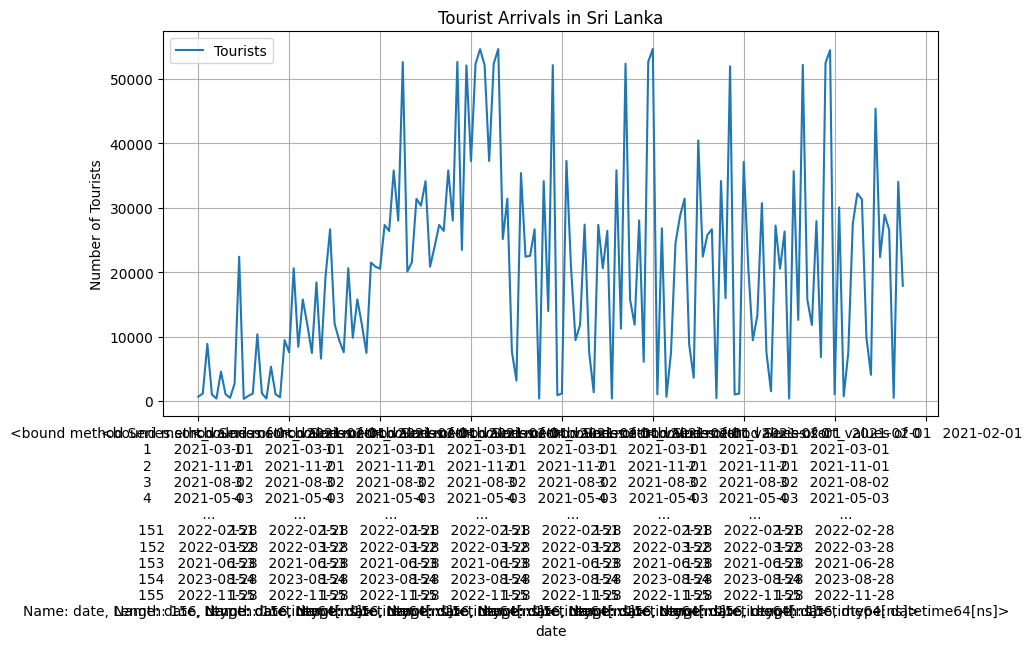

In [80]:
import matplotlib.pyplot as plt

df_tourists['date'] = df_tourists['date'].sort_values
df_tourists.plot(x='date', y=['Tourists'], figsize=(10,5), grid=True)
plt.title('Tourist Arrivals in Sri Lanka')
plt.ylabel('Number of Tourists')
plt.show()

#### 4.2 Bar Graph:

A bar graph is useful for comparing sales across different products or timeframes.
- **Purpose**: Suitable for comparing quantities of different categories.

- **Question**:  How do monthly tourist arrivals compare?

In [ ]:
monthly_sales = df_sales.groupby(df_sales['Date'].dt.month)[['No of Phones', 'No of Laptops']].sum()
monthly_sales.plot(kind='bar', figsize=(10,5))
plt.title('Monthly Sales Comparison')
plt.ylabel('Number of Units Sold')
plt.xlabel('Month')
plt.show()

#### 4.3 Histogram:
A histogram shows the distribution of sales.
- **Purpose**: To get an idea of the density and distribution of data points in continuous or certain ranges.

- **Question**: 
    - How are the sales distributed?  
    - Are there common sale values?

In [ ]:
df_sales['No of Phones'].hist(bins=30, alpha=0.5, label='Phones')
df_sales['No of Laptops'].hist(bins=30, alpha=0.5, label='Laptops')
plt.title('Sales Distribution')
plt.xlabel('Number of Units Sold')
plt.legend()
plt.show()

#### 4.4 Box Plot:
A box plot, or whisker plot, displays the summary of a set of data values, including properties like the minimum, first quartile, median, third quartile, and maximum.

- **Purpose**: To get an idea of the spread and skewness of the data and identify outliers.

- **Question**: 
    - What is the sales range? 
    - Are there any outliers?

In [ ]:
df_sales[['No of Phones', 'No of Laptops']].boxplot()
plt.title('Boxplot of Sales')
plt.ylabel('Number of Units Sold')
plt.show()

### 5.1 Correlation

Correlation measures the strength and direction of a linear relationship between two variables. It's an essential tool in statistics for understanding how one variable might influence another.

**Pearson Correlation Coefficient**

The most commonly used method to calculate correlation is the Pearson Correlation Coefficient. Its value ranges from 
−1 to 
1:


-  1: Perfect positive correlation
- −1: Perfect negative correlation
-  0: No correlation

**Key Points to Remember**

- Direction: The sign of the correlation coefficient (positive or negative) indicates the direction of the relationship.

- Strength: The closer the coefficient is to either 
1
1 or 
−
1
−1, the stronger the correlation.
- Limitations: Correlation does not imply causation. A strong correlation between two variables doesn't mean that one causes the other.
Calculating Correlation with Python

You can easily calculate the Pearson correlation coefficient using the pandas library in Python:

In [ ]:
import seaborn as sns

interested_columns = ['No of Phones','No of Laptops']
# Calculating the correlation matrix
correlation_matrix = df_sales[interested_columns].corr()

# Plotting the correlation matrix using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()